# EEG Seizure Detection: Advanced Models (Task 2)
This notebook focuses on **Task 2: Forecasting**. The objective is to develop a predictive system capable of identifying the **pre-ictal** state, defined as the window of up to 10 minutes prior to seizure onset. Unlike detection, forecasting aims to provide an _early warning signal_ while the patient is still in an **inter-ictal or pre-ictal** phase. We evaluate a comprehensive suite of classical and deep learning algorithms to establish a robust predictive benchmark.

**Notebook Workflow**

1. [**Data Loading & Preparation**](#2-data): we import pre-processed features and labels for a specific subject (e.g., `chb12`). Data is loaded from chronological splits to ensure the model is tested on "future" data and then exploded by channel.
2. [**Baseline Training**](#4-train-baselines): we evaluate 10 different classical models:
    * Linear Models: Logistic Regression, SVM.
    * Probabilistic: Naive Bayes.
    * Distance/Neighbor-based: KNN.
    * Ensemble/Tree-based: Random Forest, XGBoost, LightGBM.
    * Statistical based: Hidden Markov Chain.
    * Deep Learning: 1d Convolutional Neural Network, Recurrent Neural Network.
3. [**Handling Imbalance**](#3-helpers): we apply specific class weights and `scale_pos_weight` to address the rarity of seizure events compared to normal activity.
4. [**Hyperparameter Tuning**](#5-hypertune-top-3): we identify the top 3 performing models based on the Validation F1-score and perform an automated search (Randomized/Grid Search) to optimize their settings.
5. [**Performance Evaluation**](#6-results): Models are compared using metrics crucial for medical safety, specifically **F1-score** and **Recall (Sensitivity)**, to ensure we minimize missed seizures.
6. **Pretrained Model exportation**: we exported the best model hypertuned and pretrained on the subject chosed in order to use for further analysis.

## 1. Setup

In [5]:
import os
import sys
from pathlib import Path
import warnings

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

warnings.filterwarnings("ignore")

cur_dir = Path(os.getcwd()).resolve()
proj_dir = next(parent for parent in [cur_dir, *cur_dir.parents] if (parent / "utils").exists() and (parent / "data").exists())

from utils.models.model_classes import (
    LogisticRegressionModel,
    NaiveBayesModel,
    SVMModel,
    RandomForestModel,
    KNNModel,
    XGBModel,
    LGBModel,
)

print("Imports successful")

RANDOM_STATE = 42
N_JOBS = -1

SAVE = True
SAVE_PLOT_PATH = proj_dir / "doc" / "src" / "models"


Imports successful


## 2. Data

Subject `chb12` was selected as the primary test case due to the _high frequency of seizure events recorded_ for this patient. This provides a statistically significant number of pre-ictal transitions, which is essential for training complex models and ensuring the generalizability of the forecasting results.

To further augment the training set, we implemented a channel-agnostic approach by **pooling data from all available channels**. Instead of focusing on a single lead, this 'explosion' of samples allows the models to learn more diverse spatial representations of the pre-ictal state, significantly increasing the volume of data available for the deep learning architectures.

In [ ]:
SELECTED_SUBJ = "chb12"
SPLIT_PATH = proj_dir / "data" / "split" / "task_2" / SELECTED_SUBJ
SELECTED_FILES = sorted([f.stem for f in SPLIT_PATH.glob("*.npz")])
BALANCE_TRAIN = False

def class_counts(y):
    return np.bincount(np.asarray(y).astype(int), minlength=2)

def load_file_pooled(file_name):
    """
    Loads a file and pools all channels together as separate samples.
    Strips channel names from features to ensure column alignment.
    """
    file_path = SPLIT_PATH / f"{file_name}.npz"
    data = np.load(file_path, allow_pickle=True)
    
    orig_train_size = len(data["X_train"])
    channels = data["channels"]
    feature_names = data["feature_names"]
    
    # Pre-identify the base feature names (removing the "Channel_" prefix)
    # first channel's features as a template to select the others
    first_ch = str(channels[0])
    base_names = [name.replace(f"{first_ch}_", "") for name in feature_names if name.startswith(f"{first_ch}_")]
    
    combined_frames = {"train": [], "val": [], "test": []}
    
    for ch_name in channels:
        ch_name = str(ch_name)
        # find indices for this specific channel
        idx = [i for i, name in enumerate(feature_names) if name.startswith(f"{ch_name}_")]
        
        if len(idx) == 0: continue
            
        for split in ["train", "val", "test"]:
            X_split = data[f"X_{split}"][:, idx]
            y_split = data[f"y_{split}"]
            
            # Create frame with generic names (e.g., 'delta_pwr' instead of 'FP1-F7_delta_pwr')
            df = pd.DataFrame(X_split, columns=base_names)
            df["is_seizure"] = np.asarray(y_split).astype(int)
            # keep track of which channel the sample came from
            df["original_channel"] = ch_name 
            
            combined_frames[split].append(df)
            
    # stack all channels for each split
    final_splits = {
        split: pd.concat(combined_frames[split], ignore_index=True) 
        for split in ["train", "val", "test"]
    }
    
    print(f"Loaded {file_name} (original size = {orig_train_size})| Pooled {len(channels)} channels | New Train Size: {len(final_splits['train'])}")
    return final_splits

# 1. Load and Pool
loaded = [load_file_pooled(f_name) for f_name in SELECTED_FILES]
# 2. Global Concatenation
split_frames = {
    split: pd.concat([f[split] for f in loaded], ignore_index=True)
    for split in ["train", "val", "test"]
}
# 3. Balancing (if required)
if BALANCE_TRAIN:
    pos = split_frames["train"][split_frames["train"]["is_seizure"] == 1]
    neg = split_frames["train"][split_frames["train"]["is_seizure"] == 0].sample(len(pos), random_state=RANDOM_STATE)
    split_frames["train"] = pd.concat([pos, neg], ignore_index=True).sample(frac=1, random_state=RANDOM_STATE)
# 4. Final Audit
for split, df in split_frames.items():
    counts = class_counts(df["is_seizure"])
    print(f"{split:5s}: {df.shape} | Class distribution: {counts}")

Loaded chb12_06 (original size = 434)| Pooled 26 channels | New Train Size: 11284
Loaded chb12_08 (original size = 972)| Pooled 26 channels | New Train Size: 25272
Loaded chb12_09 (original size = 1010)| Pooled 26 channels | New Train Size: 26260
Loaded chb12_10 (original size = 530)| Pooled 26 channels | New Train Size: 13780
Loaded chb12_11 (original size = 434)| Pooled 26 channels | New Train Size: 11284
Loaded chb12_23 (original size = 1006)| Pooled 26 channels | New Train Size: 26156
Loaded chb12_33 (original size = 434)| Pooled 27 channels | New Train Size: 11718
Loaded chb12_36 (original size = 432)| Pooled 27 channels | New Train Size: 11664
Loaded chb12_38 (original size = 432)| Pooled 27 channels | New Train Size: 11664
Loaded chb12_42 (original size = 564)| Pooled 27 channels | New Train Size: 15228
train: (164310, 19) | Class distribution: [108363  55947]
val  : (52585, 19) | Class distribution: [47905  4680]
test : (54489, 19) | Class distribution: [51187  3302]


## 3. Helpers

In [7]:
def compute_class_weights(y):
    counts = class_counts(y)
    total = counts.sum()
    return {cls: total / (len(counts) * count) for cls, count in enumerate(counts) if count > 0}


def compute_scale_pos_weight(y):
    counts = class_counts(y)
    return counts[0] / counts[1] if counts[1] > 0 else 1


def positive_scores(model, X):
    if not hasattr(model, "predict_proba"):
        return None
    scores = model.predict_proba(X)
    if getattr(scores, "ndim", 1) == 2:
        return scores[:, 1] if scores.shape[1] > 1 else None
    return scores


def metrics_for(model, df):
    X, y = model.preprocess(df, is_training=False, verbose=True)
    pred = model.predict(X)
    scores = positive_scores(model, X)
    metrics = {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, average="weighted", zero_division=0),
        "recall": recall_score(y, pred, average="weighted", zero_division=0),
        "f1": f1_score(y, pred, average="weighted", zero_division=0),
        "precision_seizure": precision_score(y, pred, pos_label=1, zero_division=0),
        "recall_seizure": recall_score(y, pred, pos_label=1, zero_division=0),
        "f1_seizure": f1_score(y, pred, pos_label=1, zero_division=0),
        "roc_auc": np.nan,
    }
    if scores is not None and len(np.unique(y)) == 2:
        metrics["roc_auc"] = roc_auc_score(y, scores)
    return metrics


def fit_and_score(name, model, results, models):
    X_train, y_train = model.preprocess(split_frames["train"], is_training=True, verbose=True)
    model.train(X_train, y_train)
    row = metrics_for(model, split_frames["test"])
    row.update({f"val_{k}": v for k, v in metrics_for(model, split_frames["val"]).items()})
    row.update({f"train_{k}": v for k, v in metrics_for(model, split_frames["train"]).items()})
    results[name] = row
    models[name] = model
    print(f"{name:20s} | val_f1={row['val_f1']:.4f} | test_f1={row['f1']:.4f} | seizure_recall={row['recall_seizure']:.4f}")


## 4. Train Baselines

In [8]:
class_weights = compute_class_weights(split_frames["train"]["is_seizure"])
scale_pos_weight = compute_scale_pos_weight(split_frames["train"]["is_seizure"])

models = {
    "LogisticRegression": LogisticRegressionModel(class_weight=class_weights, n_jobs=N_JOBS, scaler=None),
    "NaiveBayes": NaiveBayesModel(scaler=None),
    # "SVM": SVMModel(class_weight=class_weights, scaler=None),
    # "KNN": KNNModel(n_jobs=N_JOBS, scaler=None),
    "RandomForest": RandomForestModel(class_weight=class_weights, n_estimators=200, n_jobs=N_JOBS, scaler=None),
    "XGBoost": XGBModel(
        eval_metric="logloss",
        scaler=None,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        n_jobs=N_JOBS,
    ),
    "LightGBM": LGBModel(class_weight=class_weights, n_estimators=200, verbose=-1, n_jobs=N_JOBS, scaler=None),
}

results = {}
trained_models = {}
for name, model in models.items():
    fit_and_score(name, model, results, trained_models)

results_df = pd.DataFrame(results).T.sort_values("val_f1", ascending=False)
results_df


[LogisticRegression] Features shape: (164310, 18), Labels shape: (164310,)
Label distribution:
is_seizure
0    0.659503
1    0.340497
Name: proportion, dtype: float64
[LogisticRegression] Analyzing multicollinearity (threshold=0.95)...
[LogisticRegression] Dropped 2 redundant features. Remaining: 16
[LogisticRegression] Starting training...
[LogisticRegression] Features shape: (54489, 18), Labels shape: (54489,)
Label distribution:
is_seizure
0    0.939401
1    0.060599
Name: proportion, dtype: float64
[LogisticRegression] Applying pre-selected 16 features.
[LogisticRegression] Features shape: (52585, 18), Labels shape: (52585,)
Label distribution:
is_seizure
0    0.911001
1    0.088999
Name: proportion, dtype: float64
[LogisticRegression] Applying pre-selected 16 features.
[LogisticRegression] Features shape: (164310, 18), Labels shape: (164310,)
Label distribution:
is_seizure
0    0.659503
1    0.340497
Name: proportion, dtype: float64
[LogisticRegression] Applying pre-selected 16 fe

,accuracy,precision,recall,f1,precision_seizure,recall_seizure,f1_seizure,roc_auc,val_accuracy,val_precision,...,val_f1_seizure,val_roc_auc,train_accuracy,train_precision,train_recall,train_f1,train_precision_seizure,train_recall_seizure,train_f1_seizure,train_roc_auc
RandomForest,0.814641,0.901883,0.814641,0.852239,0.124171,0.340097,0.181921,0.673009,0.766778,0.843220,...,0.144531,0.593885,0.929767,0.931706,0.929767,0.930266,0.872999,0.928861,0.900064,0.986740
XGBoost,0.612344,0.910257,0.612344,0.712260,0.095180,0.634464,0.165528,0.684527,0.580470,0.857803,...,0.190155,0.619456,0.622725,0.667567,0.622725,0.632532,0.462036,0.657283,0.542631,0.691846
LightGBM,0.594762,0.912299,0.594762,0.698015,0.095158,0.668383,0.166597,0.688330,0.559247,0.859424,...,0.191284,0.623446,0.640551,0.695485,0.640551,0.649871,0.481410,0.720682,0.577233,0.725150
LogisticRegression,0.489750,0.902393,0.489750,0.607674,0.075152,0.656269,0.134860,0.603494,0.486546,0.829951,...,0.138316,0.489444,0.538866,0.616139,0.538866,0.548407,0.394199,0.660035,0.493601,0.608993
NaiveBayes,0.275689,0.927348,0.275689,0.362200,0.072952,0.935494,0.135349,0.649702,0.305182,0.892350,...,0.190746,0.557930,0.436480,0.656163,0.436480,0.382832,0.367674,0.909968,0.523733,0.597684


## 5. Hypertune Top 3

Top 3 by validation F1: ['RandomForest', 'XGBoost', 'LightGBM']
Hypertuning RandomForest...
[RandomForest] Grid Search...

Best parameters found for RandomForestClassifier:
{'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 30}
[RandomForest] Train model with best params...
[RandomForest] Features shape: (164310, 18), Labels shape: (164310,)
Label distribution:
0    0.659503
1    0.340497
Name: proportion, dtype: float64
[RandomForest] Starting training...
              precision    recall  f1-score   support

           0       0.95      0.91      0.93    108363
           1       0.84      0.91      0.87     55947

    accuracy                           0.91    164310
   macro avg       0.89      0.91      0.90    164310
weighted avg       0.91      0.91      0.91    164310



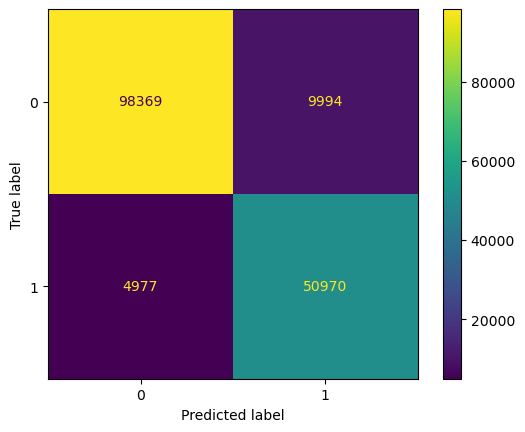

[RandomForest] Features shape: (54489, 18), Labels shape: (54489,)
Label distribution:
0    0.939401
1    0.060599
Name: proportion, dtype: float64
[RandomForest] Features shape: (52585, 18), Labels shape: (52585,)
Label distribution:
0    0.911001
1    0.088999
Name: proportion, dtype: float64
Hypertuning XGBoost...
[XGB] Grid Search...

Best parameters found for XGBClassifier:
{'subsample': 1.0, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
[XGB] Train model with best params...
[XGB] Features shape: (164310, 18), Labels shape: (164310,)
Label distribution:
is_seizure
0    0.659503
1    0.340497
Name: proportion, dtype: float64
[XGB] Starting training...
              precision    recall  f1-score   support

           0       0.83      0.65      0.73    108363
           1       0.52      0.75      0.61     55947

    accuracy                           0.68    164310
   macro avg       0.68      0.70      0.67    164310
weighted avg       0.73      0.68      0.69    

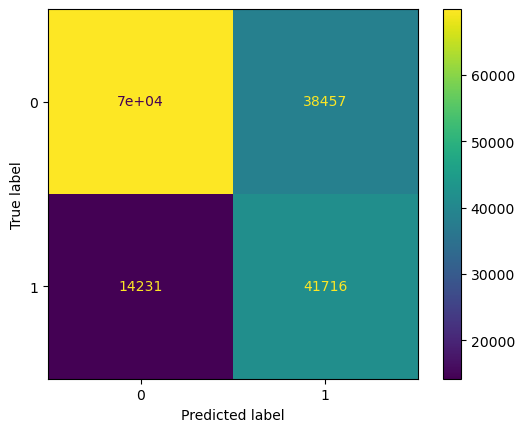

[XGB] Features shape: (54489, 18), Labels shape: (54489,)
Label distribution:
is_seizure
0    0.939401
1    0.060599
Name: proportion, dtype: float64
[XGB] Features shape: (52585, 18), Labels shape: (52585,)
Label distribution:
is_seizure
0    0.911001
1    0.088999
Name: proportion, dtype: float64
Hypertuning LightGBM...
[LGBM] Starting Randomized Search...

Best parameters found for LGBMClassifier:
{'num_leaves': 63, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1}
[LGBM] Best params: {'num_leaves': 63, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1}
[LGBM] Best validation score: 1.0000
[LGBM] Train model with best params...
[LGBM] Features shape: (164310, 18), Labels shape: (164310,)
Label distribution:
is_seizure
0    0.659503
1    0.340497
Name: proportion, dtype: float64
[LGBM] Starting training...
              precision    recall  f1-score   support

           0       0.84      0.63      0.72    108363
           1       0.52      0.76      0.61 

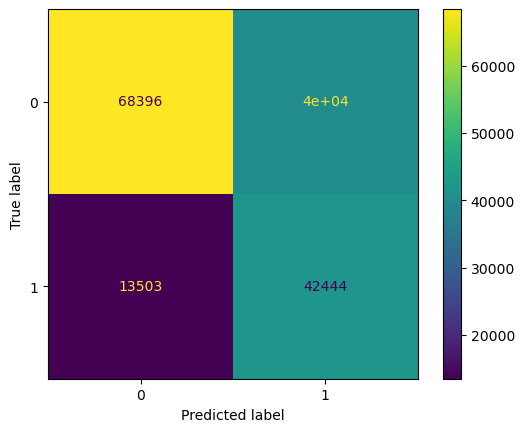

[LGBM] Features shape: (54489, 18), Labels shape: (54489,)
Label distribution:
is_seizure
0    0.939401
1    0.060599
Name: proportion, dtype: float64
[LGBM] Features shape: (52585, 18), Labels shape: (52585,)
Label distribution:
is_seizure
0    0.911001
1    0.088999
Name: proportion, dtype: float64


,best_params,search_val_f1,val_f1,f1,f1_seizure,roc_auc
RandomForest_tuned,"{'min_samples_split': 10, 'min_samples_leaf': ...",1.0,0.756947,0.803838,0.17954,0.680598
XGBoost_tuned,"{'subsample': 1.0, 'max_depth': 7, 'learning_r...",1.0,0.668163,0.718854,0.170401,0.688196
LightGBM_tuned,"{'num_leaves': 63, 'min_child_samples': 20, 'm...",1.0,0.657637,0.703708,0.171442,0.692395


In [9]:
param_grids = {
    "LogisticRegression": {"C": [0.01, 0.1, 1.0, 10.0], "solver": ["lbfgs", "liblinear"]},
    "NaiveBayes": {"var_smoothing": np.logspace(-12, -6, 7)},
    "SVM": {"C": [0.1, 1.0, 10.0], "gamma": ["scale", "auto", 0.01, 0.1], "kernel": ["rbf"]},
    "KNN": {"n_neighbors": [3, 5, 7, 11, 15], "weights": ["uniform", "distance"], "metric": ["minkowski", "manhattan"]},
    "RandomForest": {"max_depth": [None, 10, 20, 30], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4]},
    "XGBoost": {"max_depth": [3, 5, 7], "learning_rate": [0.01, 0.05, 0.1], "subsample": [0.8, 1.0], "colsample_bytree": [0.8, 1.0]},
    "LightGBM": {"max_depth": [-1, 5, 10, 20], "learning_rate": [0.01, 0.05, 0.1], "num_leaves": [15, 31, 63], "min_child_samples": [10, 20, 50]},
}

top3 = [name for name in results_df.index if name in param_grids][:3]
tuning_rows = {}
print(f"Top 3 by validation F1: {top3}")

for name in top3:
    print(f"Hypertuning {name}...")
    model = trained_models[name]
    search = model.hypertune_pipeline(
        split_frames["train"],
        split_frames["val"],
        param_grids[name],
        n_iter=12,
        scoring="f1_weighted",
        verbose=False,
    )
    tuned_name = f"{name}_tuned"
    row = metrics_for(model, split_frames["test"])
    row.update({f"val_{k}": v for k, v in metrics_for(model, split_frames["val"]).items()})
    row["best_params"] = search.best_params_
    row["search_val_f1"] = search.best_score_
    results[tuned_name] = row
    trained_models[tuned_name] = model
    tuning_rows[tuned_name] = row

results_df = pd.DataFrame(results).T.sort_values("val_f1", ascending=False)
pd.DataFrame(tuning_rows).T[["best_params", "search_val_f1", "val_f1", "f1", "f1_seizure", "roc_auc"]]


## 6. Results

,accuracy,precision,recall,f1,precision_seizure,recall_seizure,f1_seizure,roc_auc,val_accuracy,val_precision,...,train_accuracy,train_precision,train_recall,train_f1,train_precision_seizure,train_recall_seizure,train_f1_seizure,train_roc_auc,best_params,search_val_f1
RandomForest,0.814641,0.901883,0.814641,0.852239,0.124171,0.340097,0.181921,0.673009,0.766778,0.84322,...,0.929767,0.931706,0.929767,0.930266,0.872999,0.928861,0.900064,0.98674,NaN,NaN
RandomForest_tuned,0.738002,0.905646,0.738002,0.803838,0.110796,0.473047,0.17954,0.680598,0.696548,0.847779,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'min_samples_split': 10, 'min_samples_leaf': ...",1.0
XGBoost,0.612344,0.910257,0.612344,0.71226,0.09518,0.634464,0.165528,0.684527,0.58047,0.857803,...,0.622725,0.667567,0.622725,0.632532,0.462036,0.657283,0.542631,0.691846,NaN,NaN
XGBoost_tuned,0.620804,0.911645,0.620804,0.718854,0.098223,0.642641,0.170401,0.688196,0.57834,0.859833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'subsample': 1.0, 'max_depth': 7, 'learning_r...",1.0
LightGBM_tuned,0.601938,0.913906,0.601938,0.703708,0.098094,0.679588,0.171442,0.692395,0.565903,0.860925,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'num_leaves': 63, 'min_child_samples': 20, 'm...",1.0
LightGBM,0.594762,0.912299,0.594762,0.698015,0.095158,0.668383,0.166597,0.68833,0.559247,0.859424,...,0.640551,0.695485,0.640551,0.649871,0.48141,0.720682,0.577233,0.72515,NaN,NaN
LogisticRegression,0.48975,0.902393,0.48975,0.607674,0.075152,0.656269,0.13486,0.603494,0.486546,0.829951,...,0.538866,0.616139,0.538866,0.548407,0.394199,0.660035,0.493601,0.608993,NaN,NaN
NaiveBayes,0.275689,0.927348,0.275689,0.3622,0.072952,0.935494,0.135349,0.649702,0.305182,0.89235,...,0.43648,0.656163,0.43648,0.382832,0.367674,0.909968,0.523733,0.597684,NaN,NaN


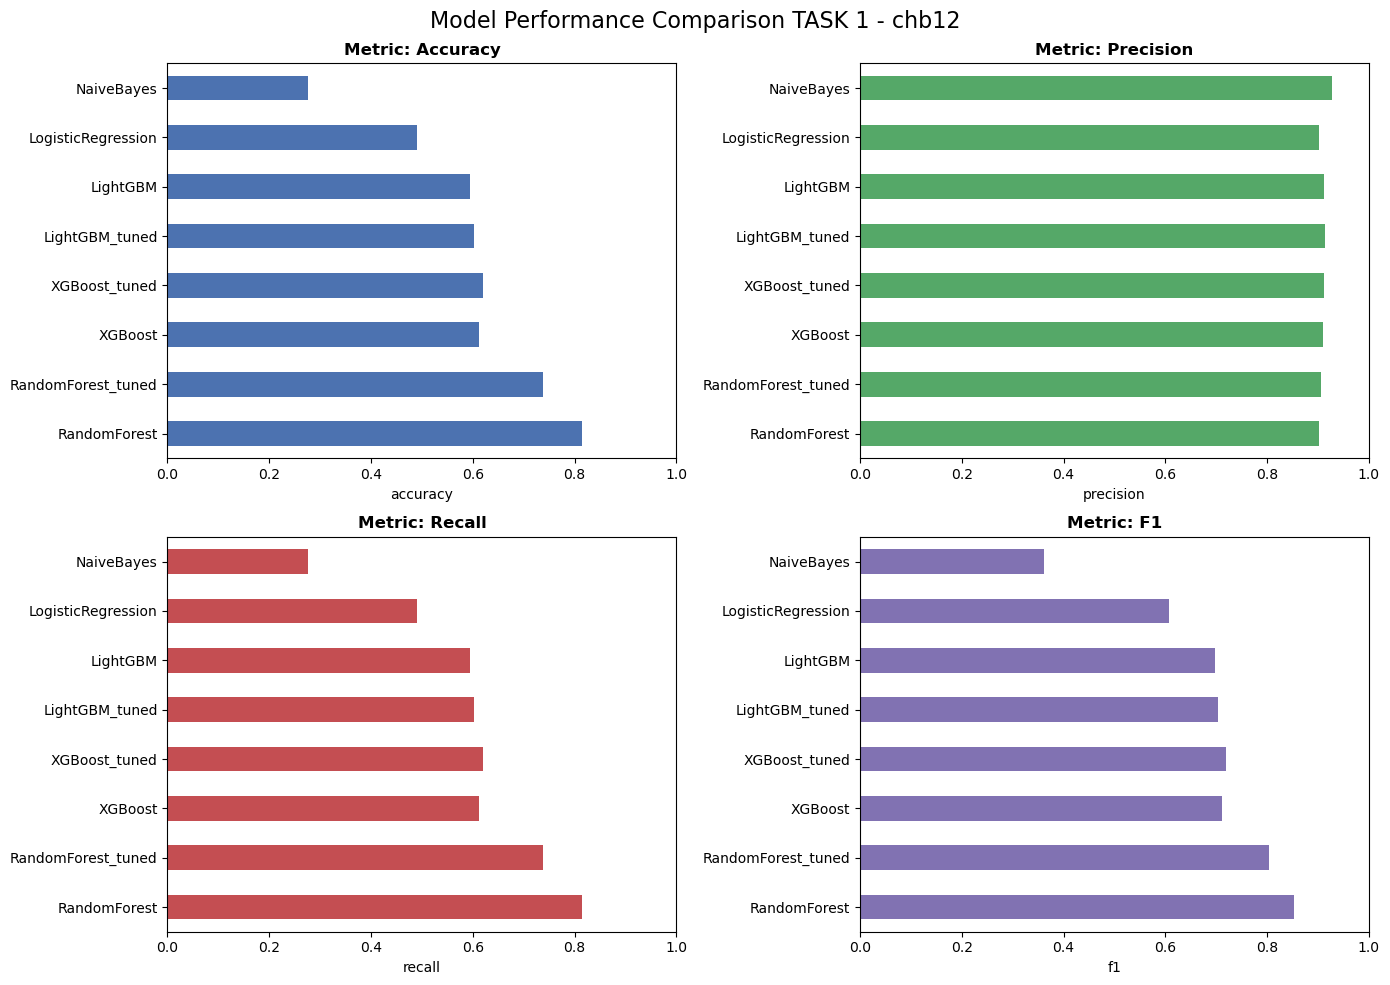

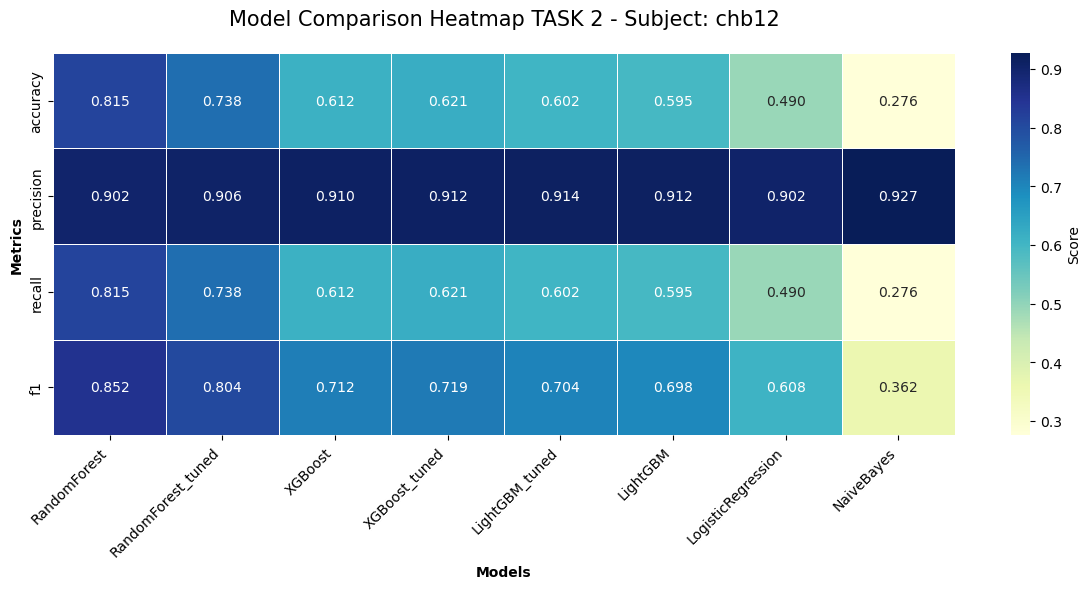

Best model by validation F1: RandomForest
accuracy                   0.814641
precision                  0.901883
recall                     0.814641
f1                         0.852239
precision_seizure          0.124171
recall_seizure             0.340097
f1_seizure                 0.181921
roc_auc                    0.673009
val_accuracy               0.766778
val_precision               0.84322
val_recall                 0.766778
val_f1                     0.800865
val_precision_seizure      0.107291
val_recall_seizure         0.221368
val_f1_seizure             0.144531
val_roc_auc                0.593885
train_accuracy             0.929767
train_precision            0.931706
train_recall               0.929767
train_f1                   0.930266
train_precision_seizure    0.872999
train_recall_seizure       0.928861
train_f1_seizure           0.900064
train_roc_auc               0.98674
best_params                     NaN
search_val_f1                   NaN
Name: RandomForest, dt

In [10]:
display(results_df)

metrics = ["accuracy", "precision", "recall", "f1"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# bar chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Model Performance Comparison TASK 1 - {SELECTED_SUBJ}", fontsize=16)
for metric, color, ax in zip(metrics, colors, axes.flatten()):
    # sorted_series = results_df[metric].astype(float).sort_values()
    results_df[metric].astype(float).plot(kind="barh", ax=ax, color=color)
    ax.set_title(f"Metric: {metric.capitalize()}", fontweight='bold')
    ax.set_xlabel(metric)
    ax.set_xlim([0, 1])
plt.tight_layout()
plt.show()

if SAVE:
    SAVE_PLOT_PATH.mkdir(parents=True, exist_ok=True)
    plot_file = SAVE_PLOT_PATH / f"task2_barchart_metrics_comparison_{SELECTED_SUBJ}.png"
    fig.savefig(plot_file, dpi=300, bbox_inches='tight')

# heatmap
heatmap_data = results_df[metrics].astype(float).T

fig = plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=.5,cbar_kws={'label': 'Score'}
)

plt.title(f"Model Comparison Heatmap TASK 2 - Subject: {SELECTED_SUBJ}", fontsize=15, pad=20)
plt.xlabel("Models", fontweight='bold')
plt.ylabel("Metrics", fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

if SAVE:
    SAVE_PLOT_PATH.mkdir(parents=True, exist_ok=True)
    plot_file = SAVE_PLOT_PATH / f"task2_heatmap_metrics_comparison_{SELECTED_SUBJ}.png"
    fig.savefig(plot_file, dpi=300, bbox_inches='tight')

best_model_name = results_df["val_f1"].idxmax()
print(f"Best model by validation F1: {best_model_name}")
print(results_df.loc[best_model_name])


## Prediction on Test split of the best model

Test metrics for RandomForest before tuning:
{'val_accuracy': 0.7667775981743843, 'val_precision': np.float64(0.8432202427637345), 'val_recall': np.float64(0.7667775981743843), 'val_f1': np.float64(0.8008650305071643), 'val_precision_seizure': np.float64(0.10729080364540182), 'val_recall_seizure': np.float64(0.22136752136752136), 'val_f1_seizure': np.float64(0.14453125), 'val_roc_auc': np.float64(0.5938847541028941)}
Test metrics for RandomForest_tuned after tuning:
{'val_accuracy': 0.6965484453741562, 'val_precision': np.float64(0.8477789112158558), 'val_recall': np.float64(0.6965484453741562), 'val_f1': np.float64(0.7569472511082047), 'val_precision_seizure': np.float64(0.11175376988225573), 'val_recall_seizure': np.float64(0.3467948717948718), 'val_f1_seizure': np.float64(0.1690360881112326), 'val_roc_auc': np.float64(0.6057754976239477)}
--------------------------------------------------
[RandomForest] Features shape: (54489, 18), Labels shape: (54489,)
Label distribution:
0    0.9

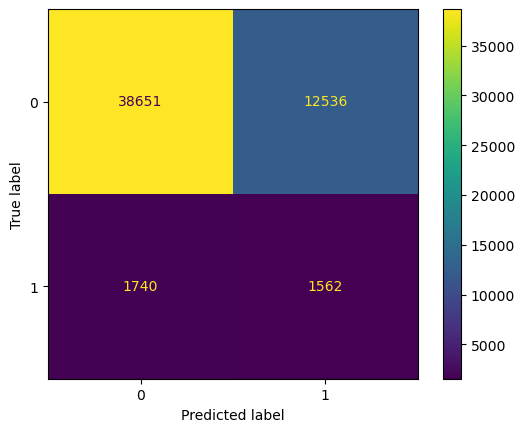

Test metrics for XGBoost before tuning:
{'val_accuracy': 0.5804697156983931, 'val_precision': np.float64(0.8578025962465428), 'val_recall': np.float64(0.5804697156983931), 'val_f1': np.float64(0.6700284876732473), 'val_precision_seizure': np.float64(0.11479987589202606), 'val_recall_seizure': np.float64(0.5534188034188035), 'val_f1_seizure': np.float64(0.19015454645571014), 'val_roc_auc': np.float64(0.619455976795242)}
Test metrics for XGBoost_tuned after tuning:
{'val_accuracy': 0.5783398307502139, 'val_precision': np.float64(0.8598330675444209), 'val_recall': np.float64(0.5783398307502139), 'val_f1': np.float64(0.668163043835644), 'val_precision_seizure': np.float64(0.1169024571854058), 'val_recall_seizure': np.float64(0.5702991452991453), 'val_f1_seizure': np.float64(0.1940314783177638), 'val_roc_auc': np.float64(0.6281632317166186)}
--------------------------------------------------
[XGB] Features shape: (54489, 18), Labels shape: (54489,)
Label distribution:
is_seizure
0    0.9394

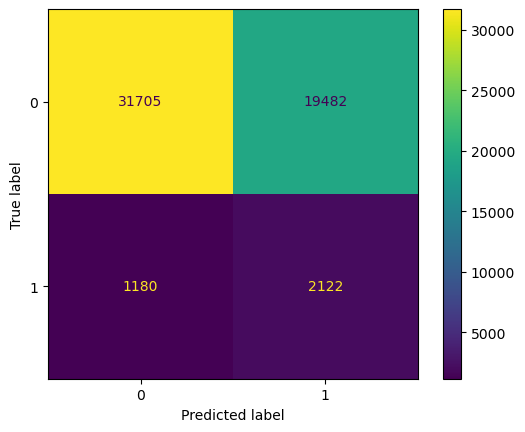

Test metrics for LightGBM before tuning:
{'val_accuracy': 0.5592469335361795, 'val_precision': np.float64(0.8594241573011534), 'val_recall': np.float64(0.5592469335361795), 'val_f1': np.float64(0.6520613281536004), 'val_precision_seizure': np.float64(0.11430835314233287), 'val_recall_seizure': np.float64(0.5856837606837607), 'val_f1_seizure': np.float64(0.1912837154122614), 'val_roc_auc': np.float64(0.6234464757082439)}
Test metrics for LightGBM_tuned after tuning:
{'val_accuracy': 0.5659028239992393, 'val_precision': np.float64(0.8609247125584258), 'val_recall': np.float64(0.5659028239992393), 'val_f1': np.float64(0.6576372396315869), 'val_precision_seizure': np.float64(0.11665047108031602), 'val_recall_seizure': np.float64(0.589957264957265), 'val_f1_seizure': np.float64(0.1947864122191259), 'val_roc_auc': np.float64(0.6260332816819614)}
--------------------------------------------------
[LGBM] Features shape: (54489, 18), Labels shape: (54489,)
Label distribution:
is_seizure
0    0.

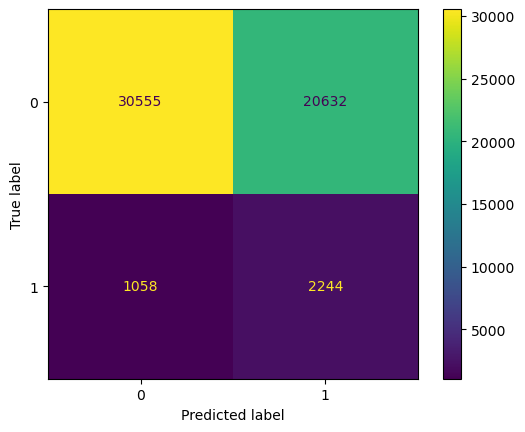

In [11]:
for name in top3:
    print(f"Test metrics for {name} before tuning:")
    print({k: v for k, v in results[name].items() if k.startswith("test_") or k.startswith("val_")})
    tuned_name = f"{name}_tuned"
    print(f"Test metrics for {tuned_name} after tuning:")
    print({k: v for k, v in results[tuned_name].items() if k.startswith("test_") or k.startswith("val_")})
    print("-" * 50)
    model = trained_models[tuned_name]
    model.test_pipeline(split_frames["test"], verbose=True)

[RandomForest] Grid Search...
Fitting 1 folds for each of 12 candidates, totalling 12 fits

Best parameters found for RandomForestClassifier:
{'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 30}
[RandomForest] Train model with best params...
[RandomForest] Features shape: (164310, 18), Labels shape: (164310,)
Label distribution:
0    0.659503
1    0.340497
Name: proportion, dtype: float64
[RandomForest] Starting training...
              precision    recall  f1-score   support

           0       0.95      0.91      0.93    108363
           1       0.84      0.91      0.87     55947

    accuracy                           0.91    164310
   macro avg       0.89      0.91      0.90    164310
weighted avg       0.91      0.91      0.91    164310



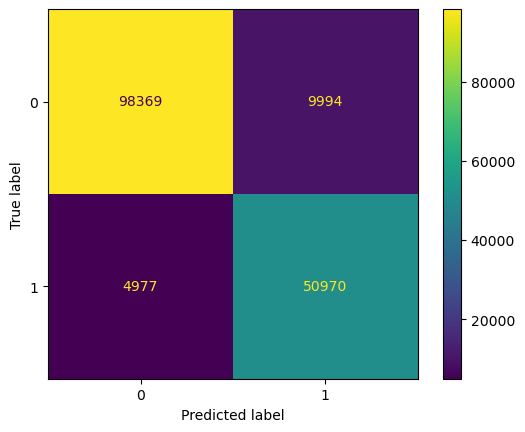

In [16]:
model = trained_models['RandomForest']
search = model.hypertune_pipeline(
            split_frames["train"],
            split_frames["val"],
            param_grids["RandomForest"],
            n_iter=12,
            scoring="f1_weighted",
            verbose=True,
        )
